In [3]:
import pandas as pd
import numpy as np
from improved_extraction import extract_fields_ultra
import os


In [5]:
results = []
img_dir = 'SROIE2019/train/img'

for img_file in os.listdir(img_dir)[:100]:

    print("Processing:", img_file)

    img_path = os.path.join(img_dir, img_file)

    vendor, date, total, text = extract_fields_ultra(img_path)

    results.append({
        'id': img_file,
        'vendor': vendor,
        'date': date,
        'total': total,
        'text_length': len(text),
        'num_lines': len([l for l in text.split('\n') if l.strip()])
    })

df = pd.DataFrame(results)

df.head()

Processing: X51006414679.jpg
Processing: X51006502533.jpg
Processing: X51008122920.jpg
Processing: X51006350763.jpg
Processing: X51006619342.jpg
Processing: X51006557198.jpg
Processing: X51007103599.jpg
Processing: X51006414721.jpg
Processing: X51005712017.jpg
Processing: X51005447861.jpg
Processing: X51008164991.jpg
Processing: X51008042791.jpg
Processing: X51007103692.jpg
Processing: X51006334699.jpg
Processing: X51005442327.jpg
Processing: X51005453802.jpg
Processing: X51006555570.jpg
Processing: X51005447840.jpg
Processing: X51006557179.jpg
Processing: X51005676540.jpg
Processing: X51007579726.jpg
Processing: X51005587267.jpg
Processing: X51006619758.jpg
Processing: X51005724554.jpg
Processing: X00016469620.jpg
Processing: X51005433492.jpg
Processing: X51008142038.jpg
Processing: X51006733494.jpg
Processing: X51006557202.jpg
Processing: X51006414429.jpg
Processing: X51007231344.jpg
Processing: X51006557195.jpg
Processing: X51006441473.jpg
Processing: X51006620414.jpg
Processing: X5

,id,vendor,date,total,text_length,num_lines
0,X51006414679.jpg,De Maximum Thai Express Sdn Bhd,14/04/2018,21.80,468,22
1,X51006502533.jpg,R&C VENTURE SDN BHD (1191015-H,19-04-2018,10.50,503,24
2,X51008122920.jpg,CW KHOO HARDWARE SDN BHD,04-05-18,None,651,27
3,X51006350763.jpg,fH HANDICRAFT & TAILTHUNG,None,104.00,518,25
4,X51006619342.jpg,WR. D.T.Y. (KUCHAT) SDN BHD,17-04-16,0.19,464,19


In [6]:
df['total_numeric'] = pd.to_numeric(df['total'], errors='coerce')

print(df['total_numeric'].describe())


count     75.000000
mean      51.208267
std       67.949183
min        0.190000
25%        8.550000
50%       27.200000
75%       61.795000
max      367.100000
Name: total_numeric, dtype: float64


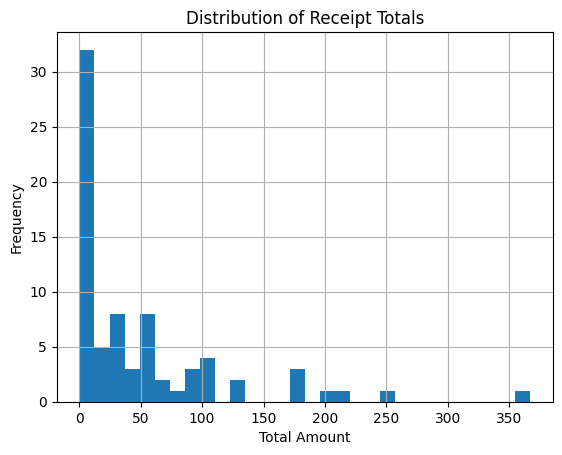

In [7]:
import matplotlib.pyplot as plt

df['total_numeric'].hist(bins=30)
plt.title("Distribution of Receipt Totals")
plt.xlabel("Total Amount")
plt.ylabel("Frequency")
plt.show()

In [8]:
from anomaly_detector import AnomalyDetector

detector = AnomalyDetector()

features_list = []

for r in results:
    features = detector.extract_features(
        r['vendor'],
        r['date'],
        r['total'],
        ""
    )
    features_list.append(features)

detector.fit(features_list)

print("Model trained!")

Model trained!
